In [135]:
import pandas as pd
from pandas_datareader import data as web
import numpy as numpy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline
import datetime as dt
import mplfinance as mpf
import yfinance as yf

In [2]:
print('hello')

hello


In [14]:
def save_csv_from_yahoofinanc(ticker,syear,smonth,sday,eyear,emonth,eday):
    start=dt.datetime(syear,smonth,sday)
    end=dt.datetime(eyear,emonth,eday)
    df=yf.download(ticker,start,end)
    df.to_csv(r'C:\Users\bolaj\Desktop\stock_py'+ticker+'.csv')
    return df

In [38]:
def get_data_csv(ticker):
    try:
        df=pd.read_csv(r'c:\Users\bolaj\Desktop|stock_py'+ticker+'.csv')
    except FileNotFoundError:
        print('file not found')
    else:
        return df

In [51]:
save_csv_from_yahoofinanc('AMZN',2020,1,1,2021,1,1)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2020-01-02,94.900497,94.900497,93.207497,93.750000,80580000
2020-01-03,93.748497,94.309998,93.224998,93.224998,75288000
2020-01-06,95.143997,95.184502,93.000000,93.000000,81236000
2020-01-07,95.343002,95.694504,94.601997,95.224998,80898000
2020-01-08,94.598503,95.550003,94.321999,94.902000,70160000
...,...,...,...,...,...
2020-12-24,158.634506,160.100006,158.449997,159.695007,29038000
2020-12-28,164.197998,165.199997,158.634506,159.699997,113736000


In [52]:
def get_data_csv(ticker):
    try:
        df=pd.read_csv(rf'c:\Users\bolaj\Desktop\stock_py'+ticker+'.csv')
    except FileNotFoundError:
        print('file not found')
    else:
        return df

In [108]:
amazon=get_data_csv('AMZN')

amazon

,Price,Close,High,Low,Open,Volume
0,Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,94.90049743652344,94.90049743652344,93.2074966430664,93.75,80580000
3,2020-01-03,93.74849700927734,94.30999755859375,93.2249984741211,93.2249984741211,75288000
4,2020-01-06,95.14399719238281,95.18450164794922,93.0,93.0,81236000
...,...,...,...,...,...,...
250,2020-12-24,158.63450622558594,160.10000610351562,158.4499969482422,159.69500732421875,29038000
251,2020-12-28,164.197998046875,165.1999969482422,158.63450622558594,159.6999969482422,113736000
252,2020-12-29,166.10000610351562,167.53250122070312,164.06100463867188,165.4969940185547,97458000
253,2020-12-30,164.29249572753906,167.10499572753906,164.12350463867188,167.0500030517578,64186000


In [109]:
amazon.describe()
amazon=amazon[(amazon['Price']!='Ticker' )&( amazon['Price']!='Date')]
amazon.set_index(amazon['Price'])
amazon=amazon.rename(columns={'Price':'Date'})



In [110]:
amazon
amazon.set_index('Date')
amazon.dtypes

Date      str
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

In [112]:
amazon['Date']=pd.to_datetime(amazon['Date'])
amazon

,Date,Close,High,Low,Open,Volume
2,2020-01-02,94.90049743652344,94.90049743652344,93.2074966430664,93.75,80580000
3,2020-01-03,93.74849700927734,94.30999755859375,93.2249984741211,93.2249984741211,75288000
4,2020-01-06,95.14399719238281,95.18450164794922,93.0,93.0,81236000
5,2020-01-07,95.34300231933594,95.69450378417969,94.60199737548828,95.2249984741211,80898000
6,2020-01-08,94.59850311279297,95.55000305175781,94.3219985961914,94.9020004272461,70160000
...,...,...,...,...,...,...
250,2020-12-24,158.63450622558594,160.10000610351562,158.4499969482422,159.69500732421875,29038000
251,2020-12-28,164.197998046875,165.1999969482422,158.63450622558594,159.6999969482422,113736000
252,2020-12-29,166.10000610351562,167.53250122070312,164.06100463867188,165.4969940185547,97458000
253,2020-12-30,164.29249572753906,167.10499572753906,164.12350463867188,167.0500030517578,64186000


In [113]:
columns=['Close','High','Low','Open','Volume']
for col in columns:
    amazon[col]=pd.to_numeric(amazon[col])

In [117]:

pd.set_option('display.float_format',lambda x:'%.2f'%x)

In [118]:
amazon.dtypes
amazon.describe()


,Date,Close,High,Low,Open,Volume
count,253,253.00,253.00,253.00,253.00,253.00
mean,2020-07-02 12:42:41.264822,134.04,135.85,132.11,134.05,98619818.18
min,2020-01-02 00:00:00,83.83,87.97,81.30,82.08,29038000.00
25%,2020-04-02 00:00:00,107.49,108.30,106.21,107.11,69486000.00
50%,2020-07-02 00:00:00,144.51,147.78,143.55,145.32,90532000.00
75%,2020-10-01 00:00:00,158.26,160.10,156.52,159.00,115786000.00
max,2020-12-31 00:00:00,176.57,177.61,174.33,177.35,311346000.00
std,NaN,27.29,27.71,26.98,27.56,39523222.44


In [119]:
#rate of return for eachdayd
def daily_return(df,ticker):
    df['return']=df['Close']/df['Close'].shift(1)-1
    df.to_csv(rf'c:\Users\bolaj\Desktop\stock_py'+ticker+'.csv')
    return df

In [120]:
daily_return(amazon,'AMZN')

,Date,Close,High,Low,Open,Volume,return
2,2020-01-02,94.90,94.90,93.21,93.75,80580000,NaN
3,2020-01-03,93.75,94.31,93.22,93.22,75288000,-0.01
4,2020-01-06,95.14,95.18,93.00,93.00,81236000,0.01
5,2020-01-07,95.34,95.69,94.60,95.22,80898000,0.00
6,2020-01-08,94.60,95.55,94.32,94.90,70160000,-0.01
...,...,...,...,...,...,...,...
250,2020-12-24,158.63,160.10,158.45,159.70,29038000,-0.00
251,2020-12-28,164.20,165.20,158.63,159.70,113736000,0.04
252,2020-12-29,166.10,167.53,164.06,165.50,97458000,0.01
253,2020-12-30,164.29,167.10,164.12,167.05,64186000,-0.01


In [131]:
def get_return_refine_time(df,syear,smonth,sday,eyear,emonth,eday):
    start=f'{syear}-{smonth}-{sday}'
    end=f'{eyear}-{emonth}-{eday}'
    mask=((df['Date']>=start) &( df['Date']<=end))
    daily_ret=df.loc[mask]['return'].mean()
    df2=df.loc[mask]
    days=df2.shape[0]
    return(days*daily_ret)


In [132]:
get_return_refine_time(amazon,2020,1,1,2021,1,1)

np.float64(0.6166402116980415)

In [ ]:
def mpf(ticker,chart_type,syear,smonth,sday,eyear,emonth,eday):
        start=f'{syear}-{smonth}-{sday}'
        end=f'{eyear}-{emonth}-{eday}'
        try:
                df=pd.read_csv(rf'c:\Users\bolaj\Desktop\stock_py'+ticker+'.csv')
        except FileNotFoundError:
                print('file not found')
        else:
                 df.index=pd.DatetimeIndex(df['Date']) 
                 df_sub=df.loc[start:end]
                 mpf.plot(df_sub, type='candle')
                 mpf.plot(df_sub, type='line')
                #  mpf.plot(df_sub, type='ohlc' mv=4)
                 fig=mpf.figure(figsize=(12,8))
                 ax=fig.add_subplot(2,1,2)
                 av=fig.add_subplot(2,1,2, sharex=ax)
                 mpf.plot(df_sub, type=chart_type, ax=ax)
                 mpf.plot(df_sub, type='line', ax=av)
                 return (df_sub,type=chart_type, mav=(3,5,7),ax=ax,volume=av,show_nontrading=True)


In [138]:
def price_plot(ticker,syear,smonth,sday,eyear,emonth,eday):
        start=f'{syear}-{smonth}-{sday}'
        end=f'{eyear}-{emonth}-{eday}'
        try:
            df=pd.read_csv(rf'c:\Users\bolaj\Desktop\stock_py'+ticker+'.csv')
        except FileNotFoundError:

            print('file not found')
        else:
             df.index=pd.DatetimeIndex(df['Date']) 
             df_sub=df.loc[start:end]
             df_np=df_sub.to_numpy()
             np_adj_close=df_np[:,5]
             date_arr=df_np[:,1]
             fig=plt.figure(figsize=(12,8),dpi=100)
             axes=fig.add_axes([0,0,1,1])
             axes.plot(date_arr,np_adj_close, color='navy')
             axes.xaxis.set_major_locator(plt.MaxNLocator(8))
             axes.grid(True,color='0.6',dashes=(5,2,1,2))
             axes.set_facecolor('#FAEBD7')


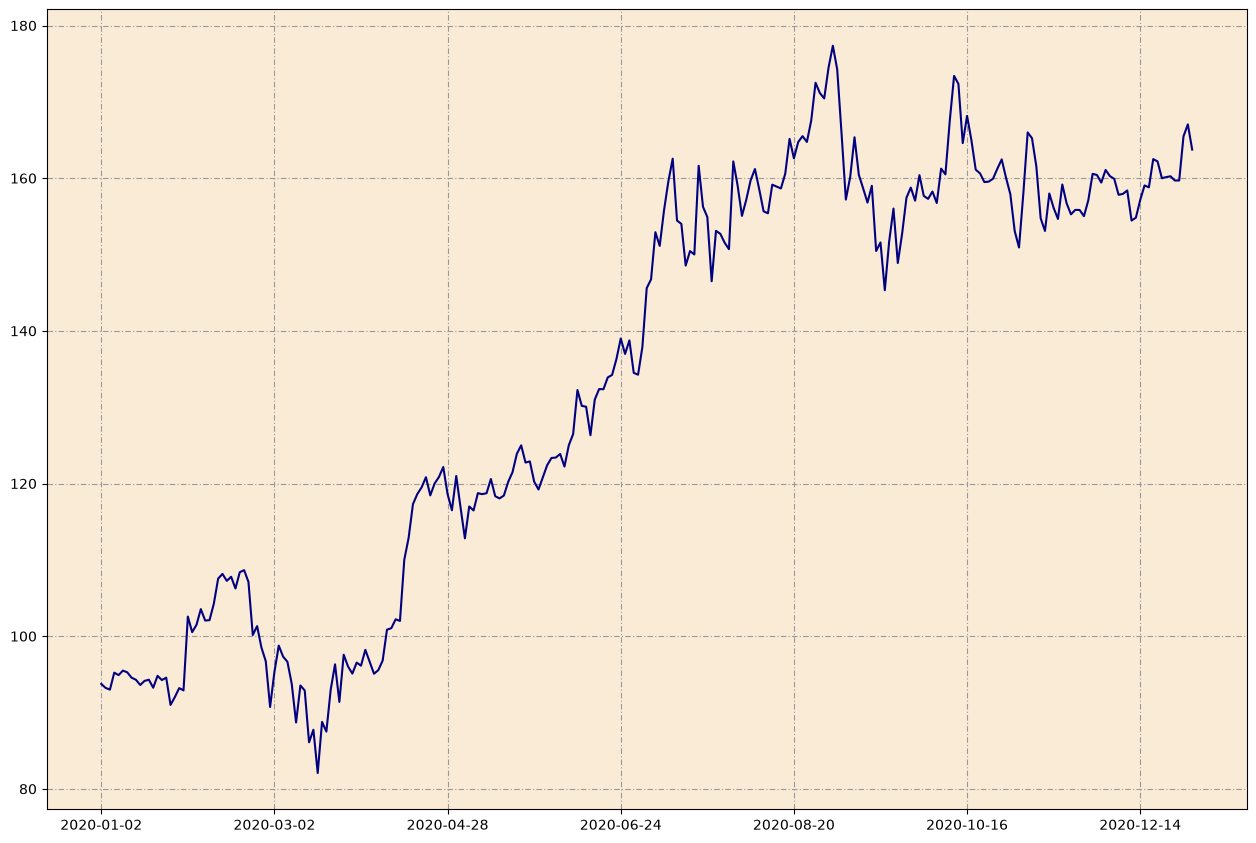

In [139]:
price_plot('AMZN',2020,1,1,2021,1,1)

In [ ]:
def download_multiple_stocks(syear,smonth,sday,eyear,emonth,eday, *args):
    for x in args:
        save_csv_from_yahoofinanc(ticker,syear,smonth,sday,eyear,emonth,eday)

In [ ]:
ticker=['FB','AAPL','NFLX','GOOG']

In [158]:
import yfinance as yf
import pandas as pd

def merge_stock(col_name, syear, smonth, sday, eyear, emonth, eday, *tickers):
    mult_df = pd.DataFrame()
    start = f'{syear}-{smonth}-{sday}'
    end   = f'{eyear}-{emonth}-{eday}'

    for x in tickers:
        df = yf.download(x, start=start, end=end)

        # Add column to merged DataFrame
        mult_df[x] = df[col_name]

        # Save CSV for each ticker
        df.to_csv(rf'C:\Users\bolaj\Desktop\stock_py{x}.csv')

    return mult_df


In [163]:
def plot_return_mul_stock(investment,stock_df):
    (stock_df/stock_df.iloc[0] * investment).plot(figsize=(15,6))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


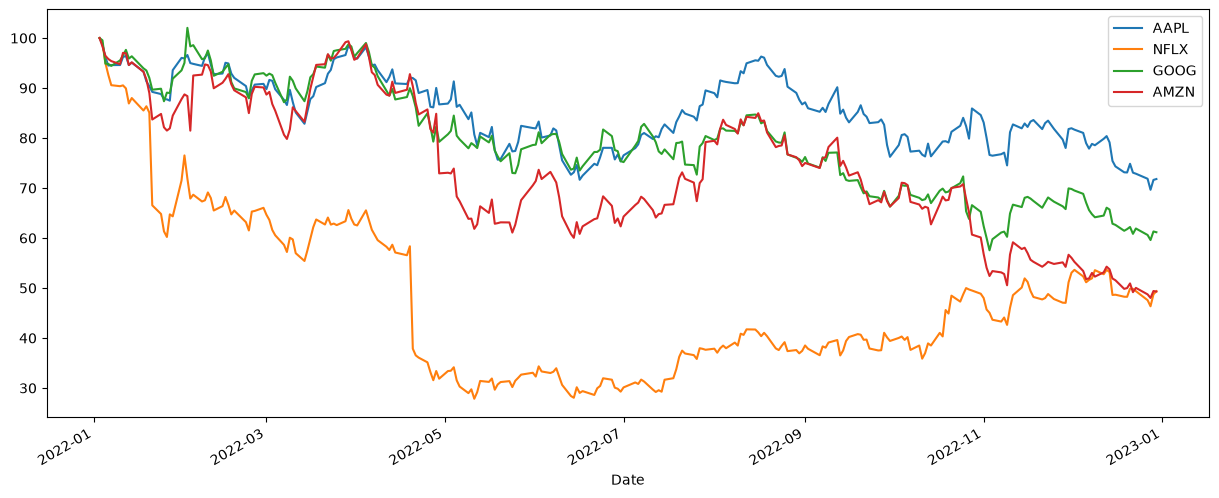

In [164]:
ticker=['AAPL','NFLX','GOOG','AMZN']
mult_df=merge_stock('Close',2022,1,1,2023,1,1,*ticker)
plot_return_mul_stock(100,mult_df)

In [165]:
def stock_mean_sd(stock_df,ticker):
    return stock_df[ticker].mean(),stock_df[ticker].std()

In [168]:
def get_multi_mean_std(stock_df):
    for stock in stock_df:
        mean,sd=stock_mean_sd(stock_df,stock)
        cov=sd/mean
        print(f'{stock} has mean={mean} standard deviation={sd} and covariance={cov}')

In [169]:
get_multi_mean_std(mult_df)

AAPL has mean=151.6746400323997 standard deviation=12.620297818965664 and covariance=0.08320638055425615
NFLX has mean=28.46392427117701 standard deviation=9.454178289260975 and covariance=0.332145989400148
GOOG has mean=114.11288114752902 standard deviation=15.866841541862984 and covariance=0.13904514006047916
AMZN has mean=126.0988188055882 standard deviation=23.904315340462265 and covariance=0.1895681146491669
